In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



In [4]:
data=pd.read_csv("log2.csv")
data.head()
data['Action'].value_counts()
data.shape

(65532, 12)

In [49]:
data.describe()

,Source Port,Destination Port,NAT Source Port,NAT Destination Port,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,pkts_received
count,65532.000000,65532.000000,65532.000000,65532.000000,6.553200e+04,6.553200e+04,6.553200e+04,6.553200e+04,65532.000000,65532.000000,65532.000000
mean,49391.969343,10577.385812,19282.972761,2671.049930,9.712395e+04,2.238580e+04,7.473815e+04,1.028660e+02,65.833577,41.399530,61.466505
std,15255.712537,18466.027039,21970.689669,9739.162278,5.618439e+06,3.828139e+06,2.463208e+06,5.133002e+03,302.461762,3218.871288,2223.332271
min,0.000000,0.000000,0.000000,0.000000,6.000000e+01,6.000000e+01,0.000000e+00,1.000000e+00,0.000000,1.000000,0.000000
25%,49183.000000,80.000000,0.000000,0.000000,6.600000e+01,6.600000e+01,0.000000e+00,1.000000e+00,0.000000,1.000000,0.000000
50%,53776.500000,445.000000,8820.500000,53.000000,1.680000e+02,9.000000e+01,7.900000e+01,2.000000e+00,15.000000,1.000000,1.000000
75%,58638.000000,15000.000000,38366.250000,443.000000,7.522500e+02,2.100000e+02,4.490000e+02,6.000000e+00,30.000000,3.000000,2.000000
max,65534.000000,65535.000000,65535.000000,65535.000000,1.269359e+09,9.484772e+08,3.208818e+08,1.036116e+06,10824.000000,747520.000000,327208.000000


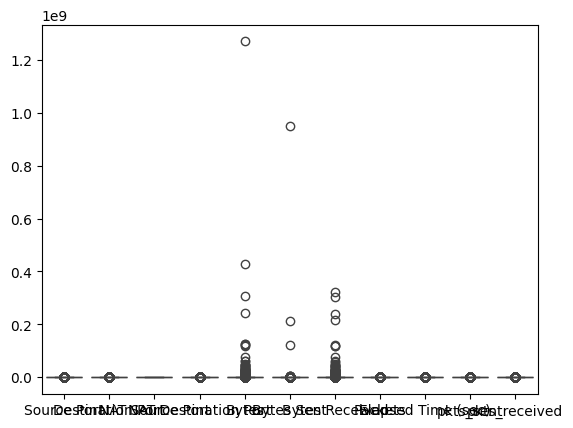

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data)
plt.show()

In [28]:
import pandas as pd

# Assuming 'df' is your dataframe
Q1 = data[['Bytes'	,'Bytes Sent']].quantile(0.25)
Q3 = data[['Bytes'	,'Bytes Sent']].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtering the outliers
df_no_outliers = data[~((data[['Bytes'	,'Bytes Sent']] < lower_bound) | (data[['Bytes'	,'Bytes Sent']] > upper_bound)).any(axis=1)]

# Alternatively, you can impute or cap the outliers instead of removing them


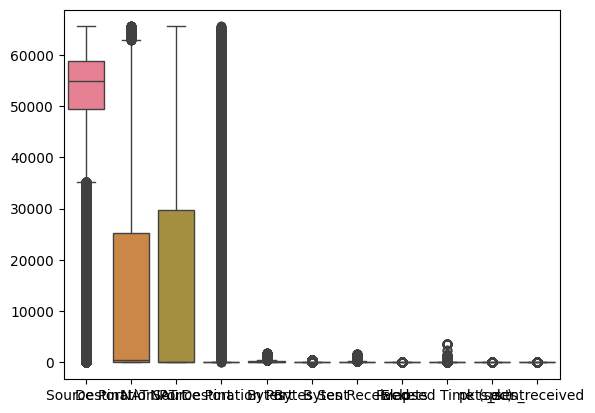

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(df_no_outliers)
plt.show()

In [11]:
import pandas as pd

# Assuming 'df' is your dataframe
Q1 = df_no_outliers[['Source Port','Destination Port']].quantile(0.25)
Q3 = df_no_outliers[['Source Port','Destination Port']].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtering the outliers
df_no_outliers2 = df_no_outliers[~((df_no_outliers[['Source Port','Destination Port']] < lower_bound) | (df_no_outliers[['Source Port','Destination Port']] > upper_bound)).any(axis=1)]

# Alternatively, you can impute or cap the outliers instead of removing them


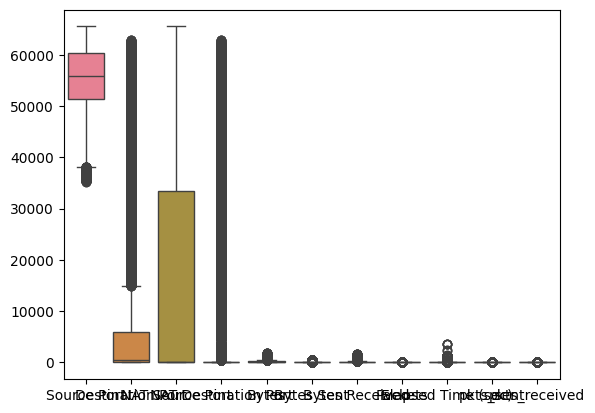

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(df_no_outliers2)
plt.show()

In [6]:
# print(data.describe())
X=data.drop('Action',axis=1)
Y=data['Action']

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,random_state=42)


In [52]:
from sklearn.ensemble import RandomForestClassifier
classifier=RandomForestClassifier(n_estimators=2,criterion="log_loss")
model=classifier.fit(X_train,Y_train)
Y_pridict=model.predict(X_test)
from sklearn.metrics import accuracy_score ,confusion_matrix,classification_report
print( "accuray of test model",accuracy_score(Y_test,Y_pridict)*100)
print( "accuray of train model",accuracy_score(Y_train,model.predict(X_train))*100)
print(confusion_matrix(Y_test,Y_pridict))
print(classification_report(Y_test,Y_pridict))


accuray of test model 99.71007858396277
accuray of train model 99.88936576061039
[[7426    5    0    0]
 [   4 3027    3    1]
 [   0   18 2613    0]
 [   0    7    0    3]]
              precision    recall  f1-score   support

       allow       1.00      1.00      1.00      7431
        deny       0.99      1.00      0.99      3035
        drop       1.00      0.99      1.00      2631
  reset-both       0.75      0.30      0.43        10

    accuracy                           1.00     13107
   macro avg       0.93      0.82      0.85     13107
weighted avg       1.00      1.00      1.00     13107



Create new model of random forest

NameError: name 'y' is not defined

reduce 

In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Update classifier with constraints to reduce overfitting
classifier = RandomForestClassifier(
    n_estimators=100,  # Increase the number of trees
    criterion="entropy",  # Use entropy instead of log_loss (log_loss isn't available in sklearn for RandomForest)
    max_depth=10,  # Limit depth of trees
    min_samples_split=5,  # Require a minimum number of samples to split a node
    min_samples_leaf=4,  # Require a minimum number of samples in a leaf node
    max_features="sqrt",  # Limit the number of features considered for splitting
    random_state=42  # Set random_state for reproducibility
)

# Fit the model
model = classifier.fit(X_train, Y_train)

# Make predictions
Y_predict = model.predict(X_test)

# Evaluate model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Accuracy of test model: ", accuracy_score(Y_test, Y_predict) * 100)
print("Accuracy of train model: ", accuracy_score(Y_train, model.predict(X_train)) * 100)
print(confusion_matrix(Y_test, Y_predict))
print(classification_report(Y_test, Y_predict))


Accuracy of test model:  99.86266880292973
Accuracy of train model:  99.84549356223175
[[7426    5    0    0]
 [   3 3029    3    0]
 [   0    0 2631    0]
 [   0    7    0    3]]
              precision    recall  f1-score   support

       allow       1.00      1.00      1.00      7431
        deny       1.00      1.00      1.00      3035
        drop       1.00      1.00      1.00      2631
  reset-both       1.00      0.30      0.46        10

    accuracy                           1.00     13107
   macro avg       1.00      0.82      0.86     13107
weighted avg       1.00      1.00      1.00     13107



In [54]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Update classifier with stronger regularization to lower accuracy
classifier = RandomForestClassifier(
    n_estimators=100,  # Reasonably high number of trees
    criterion="entropy",  # Use entropy for splitting
    max_depth=5,  # Limit depth of trees more aggressively
    min_samples_split=10,  # Require more samples to split a node
    min_samples_leaf=5,  # Require more samples to be in a leaf node
    max_features="log2",  # Consider fewer features for splits
    random_state=42  # Set random_state for reproducibility
)

# Fit the model
model = classifier.fit(X_train, Y_train)

# Make predictions
Y_predict = model.predict(X_test)

# Evaluate model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Accuracy of test model: ", accuracy_score(Y_test, Y_predict) * 100)
print("Accuracy of train model: ", accuracy_score(Y_train, model.predict(X_train)) * 100)
print(confusion_matrix(Y_test, Y_predict))
print(classification_report(Y_test, Y_predict))


Accuracy of test model:  99.85503929198138
Accuracy of train model:  99.8206962327134
[[7426    5    0    0]
 [   3 3028    4    0]
 [   0    0 2631    0]
 [   0    7    0    3]]
              precision    recall  f1-score   support

       allow       1.00      1.00      1.00      7431
        deny       1.00      1.00      1.00      3035
        drop       1.00      1.00      1.00      2631
  reset-both       1.00      0.30      0.46        10

    accuracy                           1.00     13107
   macro avg       1.00      0.82      0.86     13107
weighted avg       1.00      1.00      1.00     13107



In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Update classifier with stronger regularization and less complexity
classifier = RandomForestClassifier(
    n_estimators=50,  # Reduce the number of trees
    criterion="entropy",  # Use entropy for splitting
    max_depth=4,  # Further limit the depth of trees
    min_samples_split=20,  # Increase number of samples to split
    min_samples_leaf=10,  # Increase number of samples in leaf nodes
    max_features="log2",  # Use fewer features for each split
    random_state=42  # Set random_state for reproducibility
)

# Use cross-validation to get a more robust evaluation
cv_scores = cross_val_score(classifier, X_train, Y_train, cv=5)  # 5-fold cross-validation
print("Cross-validation scores: ", cv_scores)
print("Mean cross-validation score: ", np.mean(cv_scores) * 100)

# Fit the model
model = classifier.fit(X_train, Y_train)

# Make predictions
Y_predict = model.predict(X_test)

# Evaluate model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Accuracy of test model: ", accuracy_score(Y_test, Y_predict) * 100)
print("Accuracy of train model: ", accuracy_score(Y_train, model.predict(X_train)) * 100)
print(confusion_matrix(Y_test, Y_predict))
print(classification_report(Y_test, Y_predict))


Cross-validation scores:  [0.99771102 0.99723414 0.99771102 0.99694802 0.99732952]
Mean cross-validation score:  99.73867429661422
Accuracy of test model:  99.67193102922103
Accuracy of train model:  99.67381974248927
[[7418   13    0    0]
 [   4 3015   16    0]
 [   0    0 2631    0]
 [   3    7    0    0]]


c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

       allow       1.00      1.00      1.00      7431
        deny       0.99      0.99      0.99      3035
        drop       0.99      1.00      1.00      2631
  reset-both       0.00      0.00      0.00        10

    accuracy                           1.00     13107
   macro avg       0.75      0.75      0.75     13107
weighted avg       1.00      1.00      1.00     13107



c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [56]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Update classifier with stronger regularization and less complexity
classifier = RandomForestClassifier(
    n_estimators=50,  # Reduce the number of trees
    criterion="entropy",  # Use entropy for splitting
    max_depth=4,  # Further limit the depth of trees
    min_samples_split=20,  # Increase number of samples to split
    min_samples_leaf=10,  # Increase number of samples in leaf nodes
    max_features="log2",  # Use fewer features for each split
    random_state=42  # Set random_state for reproducibility
)

# Use cross-validation to get a more robust evaluation
cv_scores = cross_val_score(classifier, X_train, Y_train, cv=5)  # 5-fold cross-validation
print("Cross-validation scores: ", cv_scores)
print("Mean cross-validation score: ", np.mean(cv_scores) * 100)

# Fit the model with the entire training set
model = classifier.fit(X_train, Y_train)

# Make predictions on test data
Y_predict = model.predict(X_test)

# Evaluate model performance
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Accuracy of test model: ", accuracy_score(Y_test, Y_predict) * 100)
print("Accuracy of train model: ", accuracy_score(Y_train, model.predict(X_train)) * 100)
print(confusion_matrix(Y_test, Y_predict))
print(classification_report(Y_test, Y_predict))


Cross-validation scores:  [0.99771102 0.99723414 0.99771102 0.99694802 0.99732952]
Mean cross-validation score:  99.73867429661422
Accuracy of test model:  99.67193102922103
Accuracy of train model:  99.67381974248927
[[7418   13    0    0]
 [   4 3015   16    0]
 [   0    0 2631    0]
 [   3    7    0    0]]


c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

       allow       1.00      1.00      1.00      7431
        deny       0.99      0.99      0.99      3035
        drop       0.99      1.00      1.00      2631
  reset-both       0.00      0.00      0.00        10

    accuracy                           1.00     13107
   macro avg       0.75      0.75      0.75     13107
weighted avg       1.00      1.00      1.00     13107



c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

# Sample Data (Replace with actual dataset)
# Assuming X_train, Y_train, X_test, Y_test are defined

# Aggressively limit tree depth and add noise to data
classifier = RandomForestClassifier(
    n_estimators=25,  # Reduce the number of trees
    criterion="entropy",  # Use entropy for splitting
    max_depth=3,  # Further limit depth of trees
    min_samples_split=30,  # Require more samples to split
    min_samples_leaf=15,  # Require more samples to be in a leaf node
    max_features="sqrt",  # Consider only sqrt of features for each split
    random_state=42  # Ensure reproducibility
)

# Optionally, add noise to the training set to reduce model accuracy
X_train_noisy = X_train + np.random.normal(0, 0.1, X_train.shape)

# Perform cross-validation with more folds
cv_scores = cross_val_score(classifier, X_train_noisy, Y_train, cv=10)  # 10-fold cross-validation
print("Cross-validation scores: ", cv_scores)
print("Mean cross-validation score: ", np.mean(cv_scores) * 100)

# Fit the model with the noisy data
model = classifier.fit(X_train_noisy, Y_train)

# Make predictions on the test set
Y_predict = model.predict(X_test)

# Evaluate model performance
print("Accuracy of test model: ", accuracy_score(Y_test, Y_predict) * 100)
print("Accuracy of train model: ", accuracy_score(Y_train, model.predict(X_train)) * 100)
print(confusion_matrix(Y_test, Y_predict))
print(classification_report(Y_test, Y_predict))


Cross-validation scores:  [0.99637612 0.99656685 0.99599466 0.99694831 0.99675758 0.9982831
 0.99675696 0.99618466 0.9965662  0.9971385 ]
Mean cross-validation score:  99.67572940952938
Accuracy of test model:  99.62615396353094
Accuracy of train model:  99.654744873629
[[7418   13    0    0]
 [   4 3009   22    0]
 [   0    0 2631    0]
 [   3    7    0    0]]


c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

       allow       1.00      1.00      1.00      7431
        deny       0.99      0.99      0.99      3035
        drop       0.99      1.00      1.00      2631
  reset-both       0.00      0.00      0.00        10

    accuracy                           1.00     13107
   macro avg       0.75      0.75      0.75     13107
weighted avg       1.00      1.00      1.00     13107



c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

# Assuming X_train, Y_train, X_test, Y_test are already defined

# Add noise to the data to help generalize better
X_train_noisy = X_train + np.random.normal(0, 0.1, X_train.shape)
X_test_noisy = X_test + np.random.normal(0, 0.1, X_test.shape)

# Update RandomForestClassifier with stronger regularization
classifier = RandomForestClassifier(
    n_estimators=20,  # Reduce the number of trees further
    criterion="entropy",  # Use entropy for splitting
    max_depth=4,  # Limit the depth of the trees even more
    min_samples_split=30,  # Require more samples to split
    min_samples_leaf=15,  # Require more samples in each leaf node
    max_features="sqrt",  # Use fewer features for each split
    random_state=42  # Ensure reproducibility
)

# Perform cross-validation to get more robust evaluation
cv_scores = cross_val_score(classifier, X_train_noisy, Y_train, cv=10)  # 10-fold cross-validation
print("Cross-validation scores: ", cv_scores)
print("Mean cross-validation score: ", np.mean(cv_scores) * 100)

# Fit the model with noisy data
model = classifier.fit(X_train_noisy, Y_train)

# Make predictions on the test set
Y_predict = model.predict(X_test_noisy)

# Evaluate model performance
print("Accuracy of test model: ", accuracy_score(Y_test, Y_predict) * 100)
print("Accuracy of train model: ", accuracy_score(Y_train, model.predict(X_train)) * 100)
print(confusion_matrix(Y_test, Y_predict))
print(classification_report(Y_test, Y_predict))


Cross-validation scores:  [0.9978204  0.99738448 0.99803793 0.9971659  0.99607587 0.99672989
 0.99760192 0.99585786 0.99542184 0.9971659 ]
Mean cross-validation score:  99.69262000243667
Accuracy of test model:  99.7558494404883
Accuracy of train model:  99.71442274154168
[[11329     1     0     0]
 [    4  4453    28     0]
 [    0     0  3830     0]
 [    3    12     0     0]]


c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

       allow       1.00      1.00      1.00     11330
        deny       1.00      0.99      0.99      4485
        drop       0.99      1.00      1.00      3830
  reset-both       0.00      0.00      0.00        15

    accuracy                           1.00     19660
   macro avg       0.75      0.75      0.75     19660
weighted avg       1.00      1.00      1.00     19660



c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
